### Training and Deploying TensorFlow Models at Scale

In [ ]:
import keras 
import tensorflow as tf
import numpy as np 
from tensorflow import layers

##### Tensorflow serving

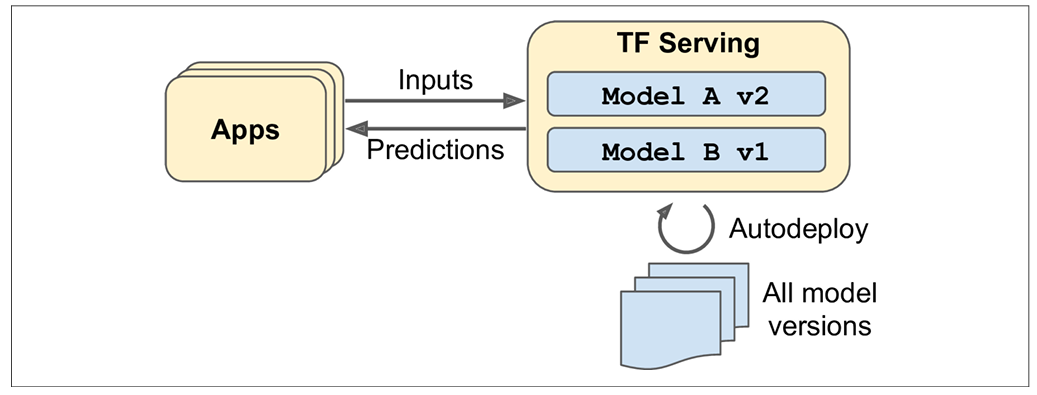

The first thing you have to do is export this model to TensroFlow SavedModel format

In [ ]:
from shlex import join


mvocab_origen = 10000
vocab_destino = 10000
latent_dim = 256

# ==========================================
# 1. ENCODER (Procesa el idioma original)
# ==========================================
encoder_inputs = keras.Input(shape=(None,), name="entrada_encoder")
enc_emb = layers.Embedding(vocab_origen, latent_dim)(encoder_inputs)

encoder_lstm = layers.LSTM(latent_dim, return_state=True, name="lstm_encoder")
# Descartamos los outputs, solo nos importan los estados de memoria (h y c)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c] # Esta es la "comprensión" de la oración

# ==========================================
# 2. DECODER (Genera el idioma destino)
# ==========================================
decoder_inputs = keras.Input(shape=(None,), name="entrada_decoder")
dec_emb = layers.Embedding(vocab_destino, latent_dim)(decoder_inputs)

decoder_lstm = layers.LSTM(latent_dim, return_sequences=True, return_state=True, name="lstm_decoder")
# El decoder inicia su trabajo usando los estados que le pasó el encoder
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = layers.Dense(vocab_destino, activation="softmax", name="salida_traduccion")
decoder_outputs = decoder_dense(decoder_outputs)

# ==========================================
# 3. COMPILACIÓN Y ENTRENAMIENTO
# ==========================================
# Juntamos todo en un modelo que recibe dos entradas y saca la predicción
model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Para entrenar (fit), le pasamos el texto original y el texto destino desplazado

history = model.fit(
    [encoder_input_data, decoder_input_data], 
    decoder_target_data,
    batch_size=64,
    epochs=100,
    validation_split=0.2
)



model_version = '0001'
model_name = 'my_model'
model_path = os.path.join(model_name, model_version)
tf.saved_model.save(model, model_path)        

In [ ]:
saved_model = tf.saved_mnodel.load(model_path)

y_pred = saved_model(tf.constant(X_new , dtype = tf.float32))


#or you can load directly  using the keras.models.load_model() function

model = keras.models.load_model(model_path)
y_pred = model.predict(tf.constant(X_new , dtype = tf.float32))-

-installing tensorflow serving

is recomendable use  docker ,which is simple to install

In [ ]:
$ docker pull tensorflow/serving 

In [ ]:
# create a docker container 

$ docker run -it --rm -p 8500:8500 -p 8501:8501 \-v "$ML_PATH/my_mnist_model:/models/my_mnist_model" \-e MODEL_NAME=my_mnist_model \
tensorflow/serving

Querying TF serving through the REST API 

In [ ]:
import json
input_data_json = json.dumps([
    'signature': 'serving_default',
    'instances': X_new.tolist()


])

input_data_json = input_data_json.encode('utf-8')

In [ ]:
#send the input data to TF Serving using the predict API



import requests


SERVER_URL = 'http://localhost:8501/v1/models/my_mnist_model:predict'
response = requests.post(SERVER_URL, data=input_data_json)
response.raise_for_status() # raise an exception in case of error
response = response.json()

In [ ]:
y_proba = np.array([response['predictions']])

y_proba.round(2)

### Querying TF Serving through the gRPC API

When trasnfering large amounts of data it is much better to use the gRPC API

In [ ]:
from tensorflow_serving.apis.predict_pb2 import PredictRequest

request = PredictRequest()
request.model_spec.name = model_name
request.model_spec.signature_name ='serving_default'

input_name = model.input_names[0]

request.inputs[input_name].CopyFrom(tf.make_tensor_proto(X_new))

In [ ]:
# next well send the request to the server and get its response (you will need the grpcio library)


import grpc
from tensorflow_serving.apis import prediction_service_pb2_grpc


channel = grpc.insecure_channel('localhost:8500')
predict_service = prediction_service_pb2_grpc.PredictionServiceStub(channel)
response = predict_service.Predict(request, timeout=10.0)

In [ ]:
# next lets convert the predictResponse protocol buffer to a tensor

output_name = model.output_names[0]
output_proto = response.outputs[output_name]
y_proba = tf.make_ndarray(output_proto)

y_proba.round(2) 

### Deploying a new model version 



In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models # Hiperparámetros de la red
vocab_origen = 10000
vocab_destino = 10000
latent_dim = 256
dropout_rate = 0.2

# ==========================================
# 1. ENCODER BIDIRECCIONAL
# ==========================================
encoder_inputs = keras.Input(shape=(None,), name="entrada_encoder")
enc_emb = layers.Embedding(vocab_origen, latent_dim, name="embedding_encoder")(encoder_inputs)
enc_emb = layers.SpatialDropout1D(dropout_rate)(enc_emb) # Dropout optimizado para secuencias

# Usamos Bidirectional. Al hacerlo, el tamaño de la memoria interna se duplica.
encoder_bilstm = layers.Bidirectional(
    layers.LSTM(latent_dim, return_sequences=True, return_state=True),
    name="bilstm_encoder"
)

# Bidirectional LSTM devuelve 5 tensores: 
# la secuencia de salida, y los estados (hidden y cell) para ambas direcciones.
encoder_outputs, forward_h, forward_c, backward_h, backward_c = encoder_bilstm(enc_emb)

# Concatenamos los estados de ambas direcciones para pasárselos al Decoder
state_h = layers.Concatenate(name="concat_h")([forward_h, backward_h])
state_c = layers.Concatenate(name="concat_c")([forward_c, backward_c])
encoder_states = [state_h, state_c]

# ==========================================
# 2. DECODER
# ==========================================
decoder_inputs = keras.Input(shape=(None,), name="entrada_decoder")
dec_emb = layers.Embedding(vocab_destino, latent_dim, name="embedding_decoder")(decoder_inputs)
dec_emb = layers.SpatialDropout1D(dropout_rate)(dec_emb)

# OJO: Como el encoder es bidireccional, el decoder necesita el doble de capacidad (latent_dim * 2)
decoder_lstm = layers.LSTM(latent_dim * 2, return_sequences=True, return_state=True, name="lstm_decoder")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

# ==========================================
# 3. MECANISMO DE ATENCIÓN (BAHDANAU / ADDITIVE)
# ==========================================
# La atención compara lo que el decoder está intentando predecir (query) 
# con toda la información que el encoder leyó (value).
attention_layer = layers.AdditiveAttention(name="atencion_bahdanau")
context_vector = attention_layer([decoder_outputs, encoder_outputs])

# Combinamos el contexto calculado por la atención con la salida estándar del decoder
decoder_combined_context = layers.Concatenate(axis=-1, name="concat_atencion_decoder")([decoder_outputs, context_vector])

# ==========================================
# 4. CAPA DE SALIDA
# ==========================================
# Capa densa final para predecir la probabilidad de cada palabra en el vocabulario destino
decoder_dense = layers.Dense(vocab_destino, activation="softmax", name="salida_traduccion")
salida_final = decoder_dense(decoder_combined_context)

# ==========================================
# 5. COMPILACIÓN DEL MODELO
# ==========================================
model2 = models.Model([encoder_inputs, decoder_inputs], salida_final, name="Traductor_Seq2Seq_Atencion")

# Adam es un optimizador mucho más robusto que RMSprop para redes con Atención
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

In [ ]:
model_version = "0002"
model_name = "my_mnist_model"
model_path = os.path.join(model_name, model_version)
tf.saved_model.save(model, model_path)

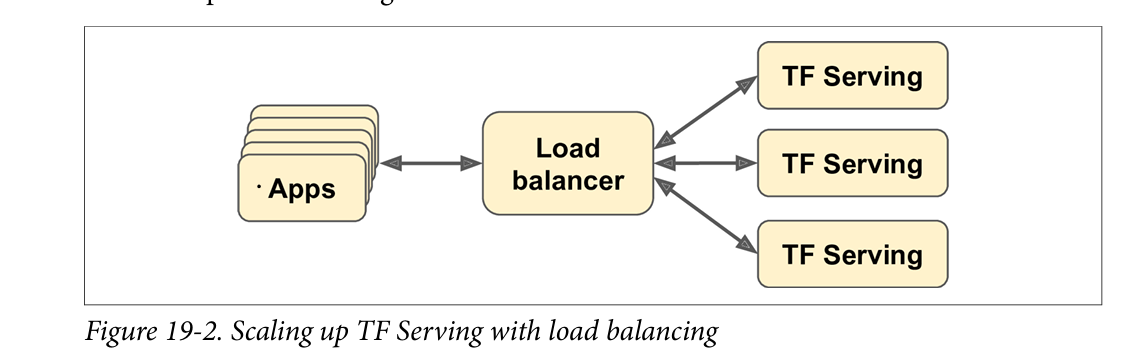